# Validation: ProjectStore + Tomography

この notebook は次を軽量に検証します。

- `ProjectStore` の cache（inducing point / obs matrix）
- traceability 付き run record 保存
- `GPT_lin_general` / `GPT_log_general` の smoke test

実データや重い RT-1 計算は使わず、小さな合成データで動作確認します。


In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
import json
import tempfile

import numpy as np
import scipy.sparse as sps

import matplotlib
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _in_jupyter_kernel = bool(_ip and getattr(_ip, "config", None) and "IPKernelApp" in _ip.config)
except Exception:
    _in_jupyter_kernel = False
if not _in_jupyter_kernel:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

import gpoloidal
import gpoloidal.rt1 as rt1
from gpoloidal.experiment import (
    ProjectStore,
    FileRef,
    CallableRef,
    VesselConfig,
    CameraConfig,
    RaytraceConfig,
    InducingPointConfig,
    ObservationMatrixConfig,
    PhantomConfig,
    NoiseConfig,
    TomographyConfig,
    ExperimentRecord,
    collect_package_versions,
    default_cache_root,
)
from gpoloidal.tomography import GPT_lin_general, GPT_log_general

print("gpoloidal", gpoloidal.__version__)


gpoloidal 0.1.0


In [2]:
scratch_root = Path(tempfile.mkdtemp(prefix="gpoloidal_validation_"))
cache_root = default_cache_root() / "validation_projectstore_tomography"
record_root = Path.cwd() / ".gpoloidal_store" / "validation_projectstore_tomography"
store = ProjectStore(cache_root=cache_root, record_root=record_root)

print("scratch_root (temporary working files):", scratch_root)
print("record_root (traceable outputs / run records):", record_root)
print("cache_root (reusable cache artifacts):", cache_root)
print(json.dumps(store.storage_roots, indent=2, ensure_ascii=False))


scratch_root (temporary working files): C:\Users\uedak\AppData\Local\Temp\gpoloidal_validation_p4a1rp1y
record_root (traceable outputs / run records): c:\Users\ueda\github_project\GPoloidal\.gpoloidal_store\validation_projectstore_tomography
cache_root (reusable cache artifacts): C:\Users\uedak\AppData\Local\gpoloidal\cache\validation_projectstore_tomography
{
  "layout_mode": "split",
  "cache_root": "C:\\Users\\uedak\\AppData\\Local\\gpoloidal\\cache\\validation_projectstore_tomography",
  "record_root": "C:\\Users\\ueda\\github_project\\GPoloidal\\.gpoloidal_store\\validation_projectstore_tomography"
}


In [3]:
# ---- 1) Inducing-point cache (hash-matched reuse) ----
point_src = scratch_root / "raw_points.npz"
np.savez(
    point_src,
    r_idc=np.array([0.5, 0.6, 0.7]),
    z_idc=np.array([0.0, 0.1, -0.1]),
    r_bd=np.array([1.0]),
    z_bd=np.array([0.0]),
)

inducing_cfg = InducingPointConfig(
    source=FileRef.from_path(point_src, note="raw inducing-point source"),
    stride=2,
    length_sq_function=CallableRef.from_callable(rt1.phantom.Length_scale_sq),
    note="validation",
)

build_counts = {"indpts": 0, "obsmat": 0}

def build_inducing_points():
    build_counts["indpts"] += 1
    return {
        "r_idc": np.array([0.5, 0.7]),
        "z_idc": np.array([0.0, -0.1]),
        "r_bd": np.array([1.0]),
        "z_bd": np.array([0.0]),
    }

inducing_arrays_1, ind_rec_1 = store.get_or_build_inducing_points(inducing_cfg, builder=build_inducing_points)
inducing_arrays_2, ind_rec_2 = store.get_or_build_inducing_points(inducing_cfg, builder=build_inducing_points)

assert build_counts["indpts"] == 1, "inducing point cache did not reuse artifact"
assert ind_rec_1.artifact_id == ind_rec_2.artifact_id
assert np.allclose(inducing_arrays_1["r_idc"], inducing_arrays_2["r_idc"])

print("inducing artifact:", ind_rec_1.artifact_id)
print("builder called:", build_counts["indpts"], "time(s)")
print("keys:", sorted(inducing_arrays_1.keys()))


inducing artifact: indpts_2ee90f4748ee0c84
builder called: 1 time(s)
keys: ['r_bd', 'r_idc', 'z_bd', 'z_idc']


In [4]:
# ---- 2) Observation-matrix cache (hash-matched reuse) ----
obs_cfg = ObservationMatrixConfig(
    method="kernel_weighting",
    lnum=41,
    vessel=VesselConfig(package_resource="gpoloidal.rt1:rt1_simple_frame.json"),
    camera=CameraConfig(
        kind="Camera2D_rphiz",
        params={
            "focal_length": 0.01,
            "location": [1.2, 0.0, 0.0],
            "center_angles": [23, 0],
            "sensor_size": [0.0082, 0.0082],
            "resolution": [8, 8],
            "rotation": 0.0,
        },
    ),
    raytrace=RaytraceConfig(nreflections=1, pass_through_first=True, ray_index_for_integral=1),
    inducing_points=inducing_cfg,
    package_versions=collect_package_versions(["gpoloidal", "zray", "numpy", "scipy"]),
    extras={"note": "dummy H for validation"},
)

H_ref = np.arange(20, dtype=float).reshape(4, 5)

def build_obsmat():
    build_counts["obsmat"] += 1
    return H_ref

H_1, ob_rec_1 = store.get_or_build_observation_matrix(obs_cfg, builder=build_obsmat)
H_2, ob_rec_2 = store.get_or_build_observation_matrix(obs_cfg, builder=build_obsmat)

assert build_counts["obsmat"] == 1, "obs matrix cache did not reuse artifact"
assert ob_rec_1.artifact_id == ob_rec_2.artifact_id
assert np.allclose(np.asarray(H_1), H_ref)
assert np.allclose(np.asarray(H_2), H_ref)

print("obs matrix artifact:", ob_rec_1.artifact_id)
print("builder called:", build_counts["obsmat"], "time(s)")
print("shape:", ob_rec_1.shape, "dtype:", ob_rec_1.dtype)


obs matrix artifact: obsmat_bc507b0f40a53342
builder called: 1 time(s)
shape: (4, 5) dtype: float64


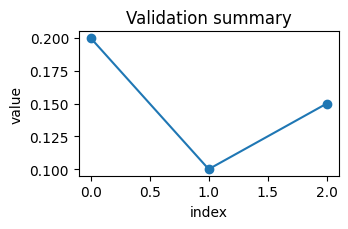

{
  "run_id": "run_02ccab778962391d",
  "trace_keys": [
    "config_hashes",
    "dependency_manifests",
    "record_hash",
    "saved_at_utc",
    "strict_traceability"
  ],
  "config_hash_keys": [
    "noise",
    "observation_matrix_config",
    "phantom",
    "references",
    "tomography"
  ],
  "dependency_manifest_keys": [
    "inducing_points",
    "observation_matrix",
    "results"
  ],
  "result_output_keys": [
    "covariance_artifact_id",
    "mean_artifact_id",
    "std_artifact_id",
    "summary_image_artifact_id"
  ]
}
summary image source: c:\Users\ueda\github_project\GPoloidal\.gpoloidal_store\validation_projectstore_tomography\validation_summary_source.png
run records dir: c:\Users\ueda\github_project\GPoloidal\.gpoloidal_store\validation_projectstore_tomography\runs


In [5]:
# ---- 3) Save tomography outputs + traceable experiment record ----
fig, ax = plt.subplots(figsize=(3.5, 2.4))
ax.plot([0, 1, 2], [0.2, 0.1, 0.15], marker="o")
ax.set_title("Validation summary")
ax.set_xlabel("index")
ax.set_ylabel("value")
fig.tight_layout()
summary_png = record_root / "validation_summary_source.png"
summary_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(summary_png, dpi=120)
plt.show()


output_artifacts = store.save_tomography_outputs(
    mean=np.array([1.0, 2.0, 3.0]),
    std=np.array([0.1, 0.2, 0.3]),
    covariance=sps.eye(3, format="csr"),
    summary_image_path=summary_png,
    prefix="validation_demo",
    extra_metadata={"source": "validation notebook"},
)

exp_record = ExperimentRecord(
    name="validation_projectstore_tomography",
    created_at_utc=datetime.now(timezone.utc).isoformat(),
    observation_matrix_artifact_id=ob_rec_1.artifact_id,
    observation_matrix_config=obs_cfg,
    phantom=PhantomConfig(
        kind="synthetic",
        name="double",
        generator=CallableRef.from_callable(rt1.phantom.get_phantom_funtion),
        params={"variant": "double"},
        ensemble_index=0,
    ),
    noise=NoiseConfig(
        model="gaussian",
        level=0.1,
        level_definition="obs_noise_level",
        profile="flat",
        seed=123,
    ),
    tomography=TomographyConfig(
        model="logGP",
        prior_kind="kernel.set_kernel",
        length_scale_factor=1.4,
        boundary_sigma=0.1,
        boundary_value=-5.0,
        prior_mean=-3.0,
        normalize=False,
        obs_noise_level=0.1,
        max_iters=20,
        tol=1e-5,
        extras={"ray_index_for_integral": 1},
    ),
    references={
        "inducing_points_artifact_id": ind_rec_1.artifact_id,
        "note": "all configs captured for traceability",
    },
    metrics={"rmse": 0.12, "chi2": 1.05},
    outputs=output_artifacts,
    notes="validation run",
)

run_id = store.save_experiment_record(exp_record, strict_traceability=True, embed_dependency_manifests=True)
run_json = store.load_experiment_record(run_id)

trace = run_json["traceability"]
summary = {
    "run_id": run_id,
    "trace_keys": sorted(trace.keys()),
    "config_hash_keys": sorted(trace["config_hashes"].keys()),
    "dependency_manifest_keys": sorted(trace["dependency_manifests"].keys()),
    "result_output_keys": sorted(output_artifacts.keys()),
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

# Show where traceable outputs were written
print("summary image source:", summary_png)
print("run records dir:", store.run_dir)


{
  "lin_closed_form_max_abs_error": 2.3314701058652076e-08,
  "log_loss_history": [
    153.23982640073643,
    252.64119418323207,
    54.03767806522787,
    23.211459494077413,
    6.988041474659109
  ],
  "log_positive_mean": true,
  "log_mll": 5.156068784196293
}


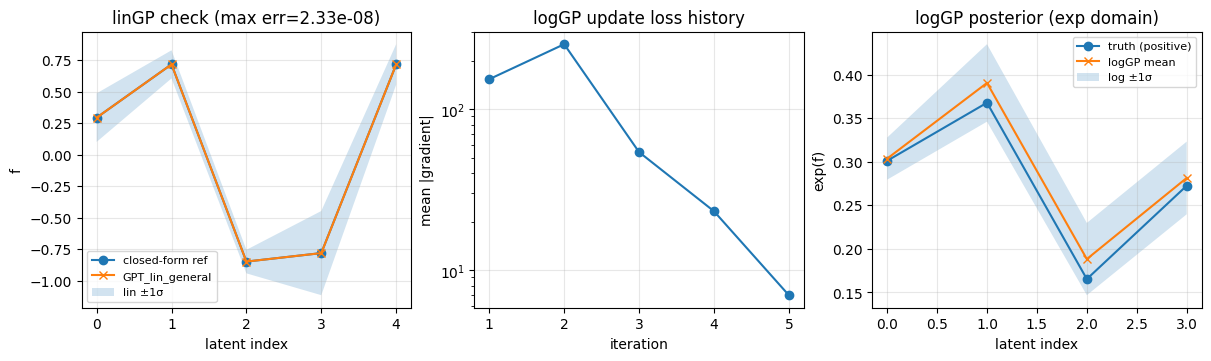

In [6]:
# ---- 4) Tomography model smoke tests (small synthetic problems) ----
rng = np.random.default_rng(0)

# Linear GP: compare against direct closed-form reference
H_lin = rng.normal(size=(9, 5))
K_lin = rng.normal(size=(5, 5))
K_lin = K_lin @ K_lin.T + 0.3 * np.eye(5)
mu_lin = rng.normal(size=5)
obs_noise_std = np.full(H_lin.shape[0], 0.25)
g_obs_lin = rng.normal(size=H_lin.shape[0])

K_inv_ref = np.linalg.inv(K_lin)
w = 1.0 / obs_noise_std
sigiH_ref = w[:, None] * H_lin
A_ref = sigiH_ref.T @ sigiH_ref + K_inv_ref
rhs_ref = sigiH_ref.T @ (w * g_obs_lin) + K_inv_ref @ mu_lin
f_ref = np.linalg.solve(A_ref, rhs_ref)

lin_model = GPT_lin_general(H=H_lin, Kf_pri=K_lin, muf_pri=mu_lin)
lin_model.set_obs(
    g_obs=g_obs_lin,
    obs_noise_profile=np.ones_like(obs_noise_std),
    normalize=False,
    obs_noise_level=float(obs_noise_std.mean()),
)
f_lin = lin_model.solve()
lin_err = float(np.max(np.abs(f_lin - f_ref)))
assert lin_err < 1e-6

# Log GP: smoke test for positivity and finite outputs
H_log = np.abs(rng.normal(size=(8, 4))) + 0.05
K_log = np.eye(4) * 0.8
mu_log = np.full(4, -1.5)
f_true_pos = np.exp(np.array([-1.2, -1.0, -1.8, -1.3]))
noise_level_log = 0.05
g_true_log = H_log @ f_true_pos
g_obs_log = g_true_log + noise_level_log * rng.normal(size=H_log.shape[0])

log_model = GPT_log_general(H=H_log, Kf_pri=K_log, muf_pri=mu_log)
log_model.set_obs(
    g_obs=g_obs_log,
    obs_noise_profile=np.ones(H_log.shape[0]),
    normalize=False,
    obs_noise_level=noise_level_log,
)

f_latent = mu_log.copy()
loss_hist = []
for _ in range(5):
    delta_f, loss = log_model.update(f_latent)
    f_latent = np.clip(f_latent + delta_f, -12.0, 8.0)
    loss_hist.append(float(loss))

log_model.postprocess(f_latent)
assert np.all(log_model.expf_mean > 0)
assert np.isfinite(log_model.mll)

print(json.dumps({
    "lin_closed_form_max_abs_error": lin_err,
    "log_loss_history": loss_hist,
    "log_positive_mean": bool(np.all(log_model.expf_mean > 0)),
    "log_mll": float(log_model.mll),
}, indent=2))


# Visualize validation outputs
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)

# Linear GP: posterior mean vs reference
x_lin = np.arange(f_ref.size)
axs[0].plot(x_lin, f_ref, marker="o", label="closed-form ref")
axs[0].plot(x_lin, f_lin, marker="x", label="GPT_lin_general")
axs[0].fill_between(
    x_lin,
    f_lin - lin_model.f_std,
    f_lin + lin_model.f_std,
    alpha=0.2,
    label="lin ±1σ",
)
axs[0].set_title(f"linGP check (max err={lin_err:.2e})")
axs[0].set_xlabel("latent index")
axs[0].set_ylabel("f")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=8)

# logGP loss history
axs[1].plot(np.arange(1, len(loss_hist) + 1), loss_hist, marker="o")
axs[1].set_title("logGP update loss history")
axs[1].set_xlabel("iteration")
axs[1].set_ylabel("mean |gradient|")
axs[1].set_yscale("log")
axs[1].grid(alpha=0.3)

# logGP positive reconstruction vs truth
x_log = np.arange(f_true_pos.size)
axs[2].plot(x_log, f_true_pos, marker="o", label="truth (positive)")
axs[2].plot(x_log, log_model.expf_mean, marker="x", label="logGP mean")
axs[2].fill_between(
    x_log,
    np.maximum(log_model.expf_mean - log_model.expf_std, 0.0),
    log_model.expf_mean + log_model.expf_std,
    alpha=0.2,
    label="log ±1σ",
)
axs[2].set_title("logGP posterior (exp domain)")
axs[2].set_xlabel("latent index")
axs[2].set_ylabel("exp(f)")
axs[2].grid(alpha=0.3)
axs[2].legend(fontsize=8)

plt.show()


In [7]:
# ---- 5) Inspect key manifest locations (cache vs record split) ----
artifact_ids = {
    "inducing_points": ind_rec_1.artifact_id,
    "observation_matrix": ob_rec_1.artifact_id,
    **output_artifacts,
}
manifest_map = {name: str(store._manifest_path(aid)) for name, aid in artifact_ids.items()}
print(json.dumps(manifest_map, indent=2, ensure_ascii=False))

print("run record path:", store.run_dir / f"{run_id}.json")


manifest_table = []
for name, aid in artifact_ids.items():
    mpath = store._manifest_path(aid)
    manifest_table.append({
        "name": name,
        "artifact_id": aid,
        "manifest_path": str(mpath),
        "under_cache_root": str(mpath).startswith(str(cache_root)),
        "under_record_root": str(mpath).startswith(str(record_root)),
    })

for row in manifest_table:
    print(json.dumps(row, ensure_ascii=False))


{
  "inducing_points": "C:\\Users\\uedak\\AppData\\Local\\gpoloidal\\cache\\validation_projectstore_tomography\\manifests\\indpts_2ee90f4748ee0c84.json",
  "observation_matrix": "C:\\Users\\uedak\\AppData\\Local\\gpoloidal\\cache\\validation_projectstore_tomography\\manifests\\obsmat_bc507b0f40a53342.json",
  "mean_artifact_id": "c:\\Users\\ueda\\github_project\\GPoloidal\\.gpoloidal_store\\validation_projectstore_tomography\\manifests\\res_d4d3819553f1feb4.json",
  "std_artifact_id": "c:\\Users\\ueda\\github_project\\GPoloidal\\.gpoloidal_store\\validation_projectstore_tomography\\manifests\\res_bd5990f6a8a74eaa.json",
  "covariance_artifact_id": "c:\\Users\\ueda\\github_project\\GPoloidal\\.gpoloidal_store\\validation_projectstore_tomography\\manifests\\res_46976a5c1ef620d1.json",
  "summary_image_artifact_id": "c:\\Users\\ueda\\github_project\\GPoloidal\\.gpoloidal_store\\validation_projectstore_tomography\\manifests\\res_e4e1bd029fe8c9aa.json"
}
run record path: c:\Users\ueda\githu

## Notes

- `cache_root` と `record_root` を分けた運用を前提にしています。
- この notebook は一時ディレクトリ（`tmp_root`）を使うので、作業中に残っても OS の temp 配下です。
- 実運用では `ProjectStore(cache_root=..., record_root=...)` を明示指定するのがおすすめです。
